# 09 - Rigorous proofs: machine-checked aircraft performance with Lean

References: Roskam & Lan, Chapters 1, 8, 9, 11; Anderson, Chapters 3 and 5.

The previous notebooks **compute** performance (01-06) and **derive** formulas with
SymPy (07-08). This notebook goes one step further and **proves** them with the
interactive theorem prover [Lean 4](https://lean-lang.org) and its mathematical
library [Mathlib](https://github.com/leanprover-community/mathlib4). Lean accepts a
theorem only if every step of the proof follows from the axioms of mathematics; the
proofs live in the `lean/` folder and are checked by `lake build`.

**What can and cannot be proved.** Lean cannot prove a *physical* law: that the drag
polar is parabolic, or that air behaves as an ideal gas, is established by
experiments. What Lean proves is that the results we use **follow exactly from the
stated model**. Every assumption is a hypothesis written in the statement (`0 < C_D0`,
`L = W cos γ`, `W' = -c W`, ...), so nothing is hidden. Compared with notebooks 07-08:

| SymPy (07-08) | Lean (this notebook) |
|---|---|
| finds where the derivative vanishes | proves that the point is the **global** maximum, and the **only** one |
| returns several roots, the physical one chosen by hand | proves which root is physical and that the other is not |
| computes an integral | proves that the integral formula is the **unique** solution of the differential equation |
| assumptions often implicit | every assumption is an explicit hypothesis |

The two tools work together. SymPy discovers identities and computes the exact
*certificates* that Lean then checks: several proofs below were written this way.

| # | Lean file | Result | Roskam & Lan |
|---|---|---|---|
| 1 | `DragPolar.lean` | maximum of $C_L/C_D$ (point E): global and unique; minimum drag | Eqns 8.18-8.19 |
| 2 | `Glide.lean` | $\tan\gamma = D/L$; minimum glide angle and maximum glide distance at point E | Sec. 8.2 |
| 3 | `MinPower.lean` | minimum power at $C_L=\sqrt{3C_{D0}/K}$ (point P); $(V_E/V_P)^4 = 3$ | Eqns 8.25-8.26, 8.75 |
| 4 | `JetClimb.lean` | jet maximum rate of climb: unique physical root, global maximum | Eqn 9.30 |
| 5 | `Breguet.lean` | weight history, endurance and range (jet and propeller) | Ch. 11 |
| 6 | `TimeToClimb.lean` | time to climb; the absolute ceiling is never reached | Eqn 9.74 |
| 7 | `Atmosphere.lean` | ISA troposphere: existence and uniqueness of the pressure law | Ch. 1 |

**How to use this notebook.** Run the cells in order. For each proof the notebook
(i) states the model and the idea of the proof, (ii) prints the Lean theorem
directly from the `.lean` file, so text and code cannot drift apart, and
(iii) cross-checks the result with SymPy and with the numerical package
`aircraft_performance`. The last section runs Lean itself, if it is installed.

**Working with the proofs in VS Code.** Install the *lean4* extension, open the
`lean/` folder, run `lake exe cache get` once (this downloads the pre-compiled
Mathlib), then `lake build`. In a `.lean` file, the *Lean Infoview* panel shows
the goal still to be proved at the cursor position (see `lean/README.md`).

### A 5-minute reading guide to Lean

```lean
theorem efficiency_le_eMax (hCD0 : 0 < CD0) (hK : 0 < K) (CL : ℝ) :
    efficiency CD0 K CL ≤ eMax CD0 K := by
  ...
```

* `theorem name (hypotheses) : statement := by ...` : the hypotheses are named
  (`hCD0`, `hK`) and the statement follows the colon. `by` starts the proof.
* `ℝ` is the set of real numbers and `Real.sqrt x` is $\sqrt{x}$. `x ^ 2` is a power
  with a natural exponent, `x ^ (y : ℝ)` a real power.
* A proof is a sequence of **tactics**, each transforming the goal:
  * `rw [lemma]` rewrites with an equation;
  * `unfold f` replaces `f` by its definition;
  * `linarith` / `nlinarith` do (non)linear arithmetic reasoning;
  * `positivity` proves `0 < e` from the form of `e`;
  * `field_simp` clears denominators and `ring` proves polynomial identities;
  * `linear_combination e` proves `lhs = rhs` by checking with `ring` that
    `lhs - rhs` equals the combination `e` of the hypotheses. This is an **exact
    algebraic certificate**, and in this notebook the certificates come from SymPy.
* `HasDerivAt f f' x` means "$f$ is differentiable at $x$ with derivative $f'$";
  `∫ x in a..b, f x` is $\int_a^b f(x)\,dx$.

In [1]:
# --- Setup -------------------------------------------------------------------
import sys
import pathlib
import re
import shutil
import subprocess

ROOT = pathlib.Path.cwd().resolve().parent          # repository root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
LEAN_DIR = ROOT / "lean"                           # the Lean project
LEAN_SRC = LEAN_DIR / "AircraftPerformance"          # one .lean file per proof

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Markdown, Math, display

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.plotting import apply_style

apply_style()
print(f"aircraft_performance v{ap.__version__}, SymPy {sp.__version__}")
print(f"Lean sources: {LEAN_SRC.relative_to(ROOT)} "
      f"({len(list(LEAN_SRC.glob('*.lean')))} files)")

aircraft_performance v1.0.0, SymPy 1.14.0
Lean sources: lean/AircraftPerformance (7 files)


In [2]:
# --- Helpers -----------------------------------------------------------------
def lean_declaration(file_name, name):
    """Return the text (doc-string + statement + proof) of a Lean theorem/lemma/def.

    Declarations in the .lean files are separated by blank lines, so we split the
    file into blocks and keep the one that declares `name`. Raising an error when
    the name is missing guarantees that this notebook and the Lean files stay in sync.
    """
    source = (LEAN_SRC / file_name).read_text(encoding="utf-8")
    pattern = re.compile(rf"^(?:noncomputable\s+)?(?:theorem|lemma|def)\s+{re.escape(name)}\b", re.M)
    for block in source.split("\n\n"):
        if pattern.search(block):
            return block.strip("\n")
    raise KeyError(f"{name} not found in {file_name}")


def show_lean(file_name, *names):
    """Display one or more Lean declarations as highlighted code."""
    text = "\n\n".join(lean_declaration(file_name, n) for n in names)
    display(Markdown(f"`lean/AircraftPerformance/{file_name}`\n```lean\n{text}\n```"))


def show(title, expr):
    """Display a title and a SymPy object as typeset mathematics."""
    display(Markdown(f"**{title}:**"), Math(sp.latex(expr)))


def check(label, computed, reference, rel_tol):
    """Compare two numbers and STOP the notebook if they disagree."""
    computed, reference = float(computed), float(reference)
    rel = abs(computed - reference) / max(abs(reference), 1e-300)
    if rel > rel_tol:
        raise AssertionError(f"{label}: {computed:.8g} vs {reference:.8g} ({100 * rel:.3g} %)")
    print(f"  [OK] {label}: {computed:.6g}  (reference {reference:.6g}, difference {100 * rel:.2g} %)")

## 1. The optimum of the parabolic drag polar (point E)

**Model.** Parabolic polar $C_D = C_{D0} + K C_L^2$ with $C_{D0}>0$, $K>0$;
efficiency $E = C_L/C_D$.

**Claim** (Roskam Eqns 8.18-8.19). For **every** $C_L$,
$$
\frac{C_L}{C_D} \le E_{max} = \frac{1}{2\sqrt{C_{D0}}\sqrt{K}} = \frac{1}{2\sqrt{C_{D0}K}},
$$
with equality **if and only if** $C_L = C_{L,E} = \sqrt{C_{D0}/K}$. In level flight
($L=W$) this means $D = W\,C_D/C_L \ge D_{min} = 2\sqrt{C_{D0}K}\,W$.

**Proof idea (no calculus).** With $a=\sqrt{C_{D0}}$, $b=\sqrt{K}$:
$$
C_D - 2ab\,C_L = a^2 + b^2C_L^2 - 2ab\,C_L = (b\,C_L - a)^2 \ge 0 ,
$$
the arithmetic-geometric mean inequality. The inequality holds for all $C_L$, so the
maximum is **global**. Equality forces the square to vanish, $b\,C_L = a$, so the
optimum is **unique**. Setting $dE/dC_L=0$, as in notebook 01, would only give a
stationary point.

In [3]:
show_lean("DragPolar.lean", "am_gm_polar", "efficiency_le_eMax", "efficiency_eq_eMax_iff", "drag_ge_min")

`lean/AircraftPerformance/DragPolar.lean`
```lean
/-- AM-GM applied to the polar:  `2 √C_D0 √K · C_L ≤ C_D(C_L)`  for every `C_L`. -/
lemma am_gm_polar (hCD0 : 0 < CD0) (hK : 0 < K) (CL : ℝ) :
    2 * (Real.sqrt CD0 * Real.sqrt K) * CL ≤ dragCoeff CD0 K CL := by
  -- instantiate the core inequality with a = √C_D0, b = √K ...
  have h := am_gm_core (Real.sqrt CD0) (Real.sqrt K) CL
  -- ... and replace (√C_D0)² by C_D0 and (√K)² by K
  rw [Real.sq_sqrt hCD0.le, Real.sq_sqrt hK.le] at h
  unfold dragCoeff
  exact h

/-- **Theorem 1 (global maximum of the efficiency).**
For every lift coefficient, `C_L / C_D ≤ E_max = 1 / (2 √C_D0 √K)`. -/
theorem efficiency_le_eMax (hCD0 : 0 < CD0) (hK : 0 < K) (CL : ℝ) :
    efficiency CD0 K CL ≤ eMax CD0 K := by
  have hD := dragCoeff_pos hCD0 hK CL
  have ha : 0 < Real.sqrt CD0 := Real.sqrt_pos.mpr hCD0
  have hb : 0 < Real.sqrt K := Real.sqrt_pos.mpr hK
  have h := am_gm_polar hCD0 hK CL
  unfold efficiency eMax
  -- cross-multiply the two fractions (both denominators are positive)
  rw [div_le_div_iff₀ hD (by positivity)]
  linarith

/-- **Theorem 3 (uniqueness of point E).**  `E(C_L) = E_max ↔ C_L = C_L,E`. -/
theorem efficiency_eq_eMax_iff (hCD0 : 0 < CD0) (hK : 0 < K) (CL : ℝ) :
    efficiency CD0 K CL = eMax CD0 K ↔ CL = clE CD0 K := by
  have hD := dragCoeff_pos hCD0 hK CL
  have ha : 0 < Real.sqrt CD0 := Real.sqrt_pos.mpr hCD0
  have hb : 0 < Real.sqrt K := Real.sqrt_pos.mpr hK
  rw [← dragCoeff_eq_iff hCD0 hK CL]
  unfold efficiency eMax
  rw [div_eq_div_iff hD.ne' (by positivity)]
  constructor <;> intro h <;> linarith

/-- **Theorem 4 (minimum drag in level flight).**
In level flight `L = W`, so `D = W · C_D / C_L`; for `C_L > 0` and `W > 0`
the drag is never below `D_min = 2 √C_D0 √K · W = W / E_max`. -/
theorem drag_ge_min (hCD0 : 0 < CD0) (hK : 0 < K) {W CL : ℝ} (hW : 0 < W) (hCL : 0 < CL) :
    2 * (Real.sqrt CD0 * Real.sqrt K) * W ≤ W * (dragCoeff CD0 K CL / CL) := by
  -- divide the AM-GM inequality by C_L > 0 ...
  have h : 2 * (Real.sqrt CD0 * Real.sqrt K) ≤ dragCoeff CD0 K CL / CL := by
    rw [le_div_iff₀ hCL]
    exact am_gm_polar hCD0 hK CL
  -- ... and multiply it by W > 0
  have hW' := mul_le_mul_of_nonneg_left h hW.le
  linarith
```

**Cross-checks.** SymPy confirms the key identity. Then the Gulfstream IV-like jet
($C_{D0}=0.015$, $K=0.08$, Anderson Example 5.1) is used for a brute-force search over
10⁶ lift coefficients, and for the package's `max_lift_to_drag` and `point_E`.

In [4]:
a, b, CL = sp.symbols("a b C_L", positive=True)
identity = sp.expand((a**2 + b**2 * CL**2) - 2 * a * b * CL - (b * CL - a)**2)
show("C_D - 2ab C_L - (b C_L - a)^2", identity)       # 0: the identity used by Lean
assert identity == 0

polar = ap.examples.business_jet_giv().polar("clean")
E_max_formula = 1 / (2 * np.sqrt(polar.CD0 * polar.K))
CL_grid = np.linspace(1e-4, 3.0, 1_000_001)
E_grid = CL_grid / polar.drag_coefficient(CL_grid)
i = np.argmax(E_grid)
print(f"E_max: formula {E_max_formula:.6f}, grid search {E_grid[i]:.6f} at C_L = {CL_grid[i]:.5f}")
check("E_max, grid vs proved formula", E_grid[i], E_max_formula, 1e-9)
check("C_L,E, grid vs sqrt(CD0/K)", CL_grid[i], np.sqrt(polar.CD0 / polar.K), 1e-4)
check("E_max, package vs proved formula", polar.max_lift_to_drag, E_max_formula, 1e-12)
check("C_L,E, package point_E", polar.point_E.CL, np.sqrt(polar.CD0 / polar.K), 1e-12)
# The theorem says that NO lift coefficient beats E_max (not only on this grid):
assert np.all(E_grid <= E_max_formula * (1 + 1e-12))

**C_D - 2ab C_L - (b C_L - a)^2:**

<IPython.core.display.Math object>

E_max: formula 14.433757, grid search 14.433757 at C_L = 0.43301
  [OK] E_max, grid vs proved formula: 14.4338  (reference 14.4338, difference 4.7e-12 %)
  [OK] C_L,E, grid vs sqrt(CD0/K): 0.433013  (reference 0.433013, difference 3.1e-05 %)
  [OK] E_max, package vs proved formula: 14.4338  (reference 14.4338, difference 0 %)
  [OK] C_L,E, package point_E: 0.433013  (reference 0.433013, difference 0 %)


## 2. Gliding flight: minimum glide angle and maximum glide distance

**Model** (Roskam Sec. 8.2). Steady straight glide, still air, flight-path angle
$\gamma$ measured downwards:
$$
D = W\sin\gamma, \qquad L = W\cos\gamma .
$$

**Claims.**
1. For $W>0$ and $-\pi/2<\gamma<\pi/2$: $\gamma = \arctan(D/L)$. This is exact (no
   small-angle approximation), and $\tan\gamma = C_D/C_L = 1/E$ does not depend on the
   weight.
2. $\gamma(C_L) \ge \gamma_{min} = \arctan(1/E_{max})$ for every $C_L>0$, with equality
   **only** at point E.
3. The still-air distance from height $h$ is $x = h/\tan\gamma = h\,E \le h\,E_{max}$,
   again with equality only at point E.

**Proof idea.** $D/L = \dfrac{W\sin\gamma}{W\cos\gamma} = \tan\gamma$ and
$\arctan(\tan\gamma)=\gamma$ on $(-\pi/2,\pi/2)$. Since $\arctan$ is **strictly
increasing**, minimising $\gamma$ is minimising $C_D/C_L$, which is Proof 1. Strict
monotonicity also transfers the uniqueness.

In [5]:
show_lean("Glide.lean", "glide_equilibrium", "minGlideAngle_le", "glideAngle_eq_min_iff", "glideDistance_le")

`lean/AircraftPerformance/Glide.lean`
```lean
/-- **Theorem 1 (glide equilibrium).**  If `L = W cos γ`, `D = W sin γ`, `W > 0` and
`-π/2 < γ < π/2`, then `γ = arctan (D / L)`: the glide angle is fixed by the ratio
`D / L` alone, independently of the weight. -/
theorem glide_equilibrium {W L D γ : ℝ} (hW : 0 < W)
    (hγ₁ : -(π / 2) < γ) (hγ₂ : γ < π / 2)
    (hL : L = W * cos γ) (hD : D = W * sin γ) :
    γ = arctan (D / L) := by
  -- D / L = (W sin γ)/(W cos γ) = sin γ / cos γ = tan γ,  and arctan (tan γ) = γ on (-π/2, π/2)
  rw [hL, hD, mul_div_mul_left _ _ hW.ne', ← tan_eq_sin_div_cos, arctan_tan hγ₁ hγ₂]

/-- **Theorem 2 (minimum glide angle).**  For every `C_L > 0`, `γ(C_L) ≥ γ_min`. -/
theorem minGlideAngle_le (hCD0 : 0 < CD0) (hK : 0 < K) {CL : ℝ} (hCL : 0 < CL) :
    minGlideAngle CD0 K ≤ glideAngle CD0 K CL := by
  unfold minGlideAngle glideAngle
  -- arctan is increasing, so it suffices to compare the arguments ...
  apply arctan_strictMono.monotone
  -- ... i.e.  2 √C_D0 √K ≤ C_D / C_L,  which is AM-GM divided by C_L > 0
  rw [le_div_iff₀ hCL]
  exact am_gm_polar hCD0 hK CL

/-- **Theorem 3 (uniqueness).**  `γ(C_L) = γ_min` if and only if `C_L = C_L,E`. -/
theorem glideAngle_eq_min_iff (hCD0 : 0 < CD0) (hK : 0 < K) {CL : ℝ} (hCL : 0 < CL) :
    glideAngle CD0 K CL = minGlideAngle CD0 K ↔ CL = clE CD0 K := by
  unfold glideAngle minGlideAngle
  -- arctan is injective, so equal angles <-> equal tangents ...
  rw [arctan_strictMono.injective.eq_iff, div_eq_iff hCL.ne']
  -- ... <-> C_D = 2 √C_D0 √K · C_L, which is the equality case of Proof 1
  exact dragCoeff_eq_iff hCD0 hK CL

/-- **Theorem 5 (maximum glide distance).**  From height `h ≥ 0` the still-air glide
distance never exceeds `h · E_max`. -/
theorem glideDistance_le (hCD0 : 0 < CD0) (hK : 0 < K) {h : ℝ} (hh : 0 ≤ h) (CL : ℝ) :
    glideDistance h (glideAngle CD0 K CL) ≤ h * eMax CD0 K := by
  rw [glideDistance_eq]
  exact mul_le_mul_of_nonneg_left (efficiency_le_eMax hCD0 hK CL) hh
```

In [6]:
gamma_grid = np.arctan(polar.drag_coefficient(CL_grid) / CL_grid)
gamma_min = np.arctan(1 / E_max_formula)
print(f"minimum glide angle: proved {np.degrees(gamma_min):.4f} deg, "
      f"grid {np.degrees(gamma_grid.min()):.4f} deg at C_L = {CL_grid[np.argmin(gamma_grid)]:.4f}")
check("gamma_min, grid vs arctan(1/E_max)", gamma_grid.min(), gamma_min, 1e-9)

h0 = 10_000.0                                        # glide from 10 km, still air
print(f"maximum glide distance from {h0:.0f} m: h E_max = {h0 * E_max_formula / 1000:.2f} km")

# Exact angle vs small-angle approximation: sin(gamma) = 1/E is only approximate
E_test = 5.0
print(f"E = {E_test}: exact gamma = {np.degrees(np.arctan(1 / E_test)):.3f} deg, "
      f"small-angle arcsin(1/E) = {np.degrees(np.arcsin(1 / E_test)):.3f} deg")

minimum glide angle: proved 3.9632 deg, grid 3.9632 deg at C_L = 0.4330
  [OK] gamma_min, grid vs arctan(1/E_max): 0.0691715  (reference 0.0691715, difference 4.7e-12 %)
maximum glide distance from 10000 m: h E_max = 144.34 km
E = 5.0: exact gamma = 11.310 deg, small-angle arcsin(1/E) = 11.537 deg


## 3. Minimum power required (point P) and $V_E/V_P = 3^{1/4}$

**Model.** Level flight with $W = \tfrac12\rho V^2 S C_L$ and
$D = \tfrac12\rho V^2 S C_D$. The power required is $P = DV$.

**Claims.**
1. $P^2 = \dfrac{2W^3}{\rho S}\,\dfrac{C_D^2}{C_L^3}$. At a given weight and altitude,
   **minimum power** is therefore the same as **maximum** $C_L^3/C_D^2$, i.e. maximum
   $C_L^{3/2}/C_D$ (Roskam Eqns 8.25-8.26).
2. $C_L^3/C_D^2$ has its global maximum at $C_{L,P}=\sqrt{3}\sqrt{C_{D0}}/\sqrt{K}
   = \sqrt{3C_{D0}/K}$.
3. $V_E^2 = \sqrt3\,V_P^2$, i.e. $(V_E/V_P)^4 = 3$ (Roskam Eqn 8.75).

**Proof idea.** With $a=\sqrt{C_{D0}}$, $b=\sqrt K$, $r=\sqrt3$ (so $r^2=3$), the
polynomial identity
$$
3r\,(a^2+b^2C_L^2)^2 - 16\,a\,b^3\,C_L^3 = (b\,C_L - r\,a)^2\,(3r\,b^2C_L^2 + 2ab\,C_L + r\,a^2)
$$
holds modulo $r^2=3$. The right-hand side is a square times a positive factor, so
$16ab^3C_L^3 \le 3\sqrt3\,C_D^2$ for every $C_L\ge0$, with equality at $b\,C_L = r\,a$.
Lean avoids the fractional power $C_L^{3/2}$ completely.

**How the identity was found.** SymPy factorises the difference over the field
$\mathbb{Q}(\sqrt3)$ (option `extension=sp.sqrt(3)`):

In [7]:
u_ = sp.symbols("u", positive=True)              # u = b C_L / a  (dimensionless)
difference = 3 * sp.sqrt(3) * (1 + u_**2)**2 - 16 * u_**3
show("3 sqrt(3) (1+u^2)^2 - 16 u^3  factorised over Q(sqrt 3)",
     sp.factor(difference, extension=sp.sqrt(3)))

# The certificate for Lean's linear_combination: the identity holds modulo r^2 = 3
a_, b_, r_, c_ = sp.symbols("a b r C_L")
lhs = 3 * r_ * (a_**2 + b_**2 * c_**2)**2 - 16 * a_ * b_**3 * c_**3
rhs = (b_ * c_ - r_ * a_)**2 * (3 * r_ * b_**2 * c_**2 + 2 * a_ * b_ * c_ + r_ * a_**2)
quotient, remainder = sp.div(sp.expand(lhs - rhs), r_**2 - 3, r_)
show("(lhs - rhs) / (r^2 - 3)  = coefficient used in `power_identity`", sp.factor(quotient))
assert remainder == 0

**3 sqrt(3) (1+u^2)^2 - 16 u^3  factorised over Q(sqrt 3):**

<IPython.core.display.Math object>

**(lhs - rhs) / (r^2 - 3)  = coefficient used in `power_identity`:**

<IPython.core.display.Math object>

In [8]:
show_lean("MinPower.lean", "power_identity", "cube_div_sq_le", "speed_ratio_pow_four")

`lean/AircraftPerformance/MinPower.lean`
```lean
/-- Polynomial identity behind Proof 3 (valid whenever `r² = 3`). -/
lemma power_identity {a b r CL : ℝ} (hr : r ^ 2 = 3) :
    3 * r * (a ^ 2 + b ^ 2 * CL ^ 2) ^ 2 - 16 * a * b ^ 3 * CL ^ 3
      = (b * CL - r * a) ^ 2 * (3 * r * b ^ 2 * CL ^ 2 + 2 * a * b * CL + r * a ^ 2) := by
  linear_combination (6 * a * b ^ 3 * CL ^ 3 - 3 * r * a ^ 2 * b ^ 2 * CL ^ 2 - r * a ^ 4) * hr

/-- **Theorem 4 (global maximum of `C_L³ / C_D²` at point P).** -/
theorem cube_div_sq_le (hCD0 : 0 < CD0) (hK : 0 < K) {CL : ℝ} (hCL : 0 ≤ CL) :
    CL ^ 3 / dragCoeff CD0 K CL ^ 2 ≤ clP CD0 K ^ 3 / dragCoeff CD0 K (clP CD0 K) ^ 2 := by
  have hD := dragCoeff_pos hCD0 hK CL
  have hDP := dragCoeff_pos hCD0 hK (clP CD0 K)
  have hP : 0 ≤ clP CD0 K := by unfold clP; positivity
  have hr : 0 < Real.sqrt 3 := Real.sqrt_pos.mpr (by norm_num)
  have hle := power_factor_le hCD0 hK hCL
  have heq := power_factor_clP hCD0 hK
  -- multiply Theorem 2 by C_L,P³ ≥ 0
  have h1 := mul_le_mul_of_nonneg_right hle (pow_nonneg hP 3)
  -- 3√3 · (C_L³ C_D(P)²) ≤ 3√3 · (C_L,P³ C_D(C_L)²), using Theorem 3
  have h3 : 3 * Real.sqrt 3 * (CL ^ 3 * dragCoeff CD0 K (clP CD0 K) ^ 2)
      ≤ 3 * Real.sqrt 3 * (clP CD0 K ^ 3 * dragCoeff CD0 K CL ^ 2) := by
    rw [show 3 * Real.sqrt 3 * (CL ^ 3 * dragCoeff CD0 K (clP CD0 K) ^ 2)
        = CL ^ 3 * (3 * Real.sqrt 3 * dragCoeff CD0 K (clP CD0 K) ^ 2) by ring, ← heq]
    linarith
  rw [div_le_div_iff₀ (by positivity) (by positivity)]
  exact le_of_mul_le_mul_left h3 (by positivity)

/-- **Corollary (Roskam Eqn 8.75).**  `(V_E / V_P)⁴ = 3`, i.e. `V_E = 3^{1/4} V_P ≈ 1.316 V_P`. -/
theorem speed_ratio_pow_four (hCD0 : 0 < CD0) (hK : 0 < K) {W ρ S V_E V_P : ℝ}
    (hρ : 0 < ρ) (hS : 0 < S) (hVP : 0 < V_P)
    (hE : V_E ^ 2 = levelSpeedSq W ρ S (clE CD0 K))
    (hP : V_P ^ 2 = levelSpeedSq W ρ S (clP CD0 K)) :
    (V_E / V_P) ^ 4 = 3 := by
  have hVP' := hVP.ne'
  have h1 : V_E ^ 2 = Real.sqrt 3 * V_P ^ 2 := by rw [hE, hP, speedSq_clE hCD0 hK hρ hS]
  calc (V_E / V_P) ^ 4 = (V_E ^ 2) ^ 2 / (V_P ^ 2) ^ 2 := by ring
    _ = (Real.sqrt 3 * V_P ^ 2) ^ 2 / (V_P ^ 2) ^ 2 := by rw [h1]
    _ = 3 := by
      rw [mul_pow, Real.sq_sqrt (by norm_num : (0 : ℝ) ≤ 3)]
      field_simp <;> ring
```

In [9]:
F_grid = CL_grid**3 / polar.drag_coefficient(CL_grid)**2
CL_P = np.sqrt(3 * polar.CD0 / polar.K)
print(f"max C_L^3/C_D^2: grid at C_L = {CL_grid[np.argmax(F_grid)]:.5f}, proved sqrt(3 CD0/K) = {CL_P:.5f}")
check("C_L,P, grid vs proved value", CL_grid[np.argmax(F_grid)], CL_P, 1e-4)
check("C_L,P, package point_P", polar.point_P.CL, CL_P, 1e-12)

jet = ap.examples.business_jet_giv()
V_E = ap.aerodynamics.speed_at_polar_point(jet.weight, jet.wing_area, 1.225, polar.point_E)
V_P = ap.aerodynamics.speed_at_polar_point(jet.weight, jet.wing_area, 1.225, polar.point_P)
print(f"sea level: V_E = {V_E:.2f} m/s, V_P = {V_P:.2f} m/s")
check("(V_E / V_P)^4, package vs proved value 3", (V_E / V_P)**4, 3.0, 1e-12)

max C_L^3/C_D^2: grid at C_L = 0.75000, proved sqrt(3 CD0/K) = 0.75000
  [OK] C_L,P, grid vs proved value: 0.75  (reference 0.75, difference 3.3e-07 %)
  [OK] C_L,P, package point_P: 0.75  (reference 0.75, difference 0 %)
sea level: V_E = 117.78 m/s, V_P = 89.49 m/s
  [OK] (V_E / V_P)^4, package vs proved value 3: 3  (reference 3, difference 4.4e-14 %)


## 4. Maximum rate of climb of a jet (Roskam Eqn 9.30)

**Model.** Shallow climb ($L\approx W$), thrust $T$ independent of speed, parabolic
polar. The drag is $D(V) = AV^2 + B/V^2$, with $A=\tfrac12\rho SC_{D0}$ and
$B = 2KW^2/(\rho S)$. The rate of climb is $RC = (T-D)V/W$, so we study
$$
W\cdot RC(V) = TV - AV^3 - \frac{B}{V} \qquad(\texttt{rcW}).
$$

**Claims.**
1. $\dfrac{d}{dV}(W\cdot RC) = T - 3AV^2 + B/V^2$. For $V\ne0$ this vanishes **iff**
   $x = V^2$ solves $3Ax^2 - Tx - B = 0$.
2. That quadratic has **exactly one positive root**,
   $x^* = \dfrac{T + \sqrt{T^2+12AB}}{6A}$ (Roskam Eqn 9.30). The other root is
   **negative**, so it is not physical. In notebook 07, `solve()` returned both.
3. $V^* = \sqrt{x^*}$ is the **global** maximum of the rate of climb over all $V>0$.

**Proof idea.** Uniqueness comes from completing the square:
$(6Ax - T)^2 = T^2+12AB$, and $6Ax - T>0$ for any positive root (otherwise $B<0$).
The global maximum follows from an exact identity, valid when $V_s$ is stationary:
$$
W\,RC(V_s) - W\,RC(V) = (V_s - V)^2\Big(A(2V_s+V) + \frac{B}{V\,V_s^2}\Big) \ \ge 0 .
$$

**How the identity was found.** Treat $V^{-1}$ and $V_s^{-1}$ as extra variables $w$,
$w_s$ with $Vw=1$ and $V_sw_s=1$. Dividing the difference of the two sides by the
hypotheses (SymPy `reduced`, i.e. multivariate polynomial division) gives remainder 0,
and the quotients are exactly the coefficients of Lean's `linear_combination`:

In [10]:
T, A, B, V, Vs, w, ws = sp.symbols("T A B V V_s w w_s")
rcW = lambda v, winv: T * v - A * v**3 - B * winv          # W·RC with 1/V written as w
goal = rcW(Vs, ws) - rcW(V, w) - (Vs - V)**2 * (A * (2 * Vs + V) + B * w * ws**2)
hypotheses = [T - 3 * A * Vs**2 + B * ws**2,   # stationarity at V_s
              V * w - 1,                       # w   = 1/V
              Vs * ws - 1]                     # w_s = 1/V_s
quotients, remainder = sp.reduced(sp.expand(goal), hypotheses, T, w, ws, A, B, V, Vs)
print("remainder:", remainder)
for h_, q_ in zip(["stationarity", "V w = 1", "Vs ws = 1"], quotients):
    display(Markdown(f"coefficient of *{h_}*:"), Math(sp.latex(sp.factor(q_))))
assert remainder == 0

remainder: 0


coefficient of *stationarity*:

<IPython.core.display.Math object>

coefficient of *V w = 1*:

<IPython.core.display.Math object>

coefficient of *Vs ws = 1*:

<IPython.core.display.Math object>

In [11]:
show_lean("JetClimb.lean", "stationary_iff", "quadratic_root_unique", "other_root_neg",
          "rcW_le_of_stationary", "rcW_le_best")

`lean/AircraftPerformance/JetClimb.lean`
```lean
/-- **Theorem 4.**  For `V ≠ 0`:  `T - 3 A V² + B / V² = 0  ↔  3 A (V²)² - T V² - B = 0`. -/
theorem stationary_iff {T A B V : ℝ} (hV : V ≠ 0) :
    T - 3 * A * V ^ 2 + B / V ^ 2 = 0 ↔ 3 * A * (V ^ 2) ^ 2 - T * V ^ 2 - B = 0 := by
  have h2 : V * V⁻¹ = 1 := mul_inv_cancel₀ hV
  constructor
  · intro hs
    linear_combination (-V ^ 2) * hs + B * (V * V⁻¹ + 1) * h2
  · intro hq
    linear_combination (-(V⁻¹) ^ 2) * hq - (T - 3 * A * V ^ 2) * (1 + V * V⁻¹) * h2

/-- **Theorem 5a (uniqueness).**  A POSITIVE root of `3 A x² - T x - B = 0` (`A, B > 0`)
is necessarily `x* = (T + √(T² + 12 A B)) / (6 A)`. -/
theorem quadratic_root_unique (hA : 0 < A) (hB : 0 < B) {x : ℝ} (hx : 0 < x)
    (hq : 3 * A * x ^ 2 - T * x - B = 0) : x = bestSpeedSq T A B := by
  -- completing the square:  (6 A x - T)² = T² + 12 A B
  have hsq : (6 * A * x - T) ^ 2 = T ^ 2 + 12 * A * B := by linear_combination 12 * A * hq
  -- the base is non-negative: otherwise B = 3 A x² - T x would be negative
  have hpos : 0 ≤ 6 * A * x - T := by nlinarith [mul_pos hA (mul_pos hx hx)]
  -- hence √(T² + 12 A B) = 6 A x - T
  have hs : Real.sqrt (T ^ 2 + 12 * A * B) = 6 * A * x - T := by
    rw [← hsq]
    exact Real.sqrt_sq hpos
  unfold bestSpeedSq
  rw [hs, eq_div_iff (by positivity)]
  ring

/-- **Theorem 5c.**  The other root `(T - √(T² + 12 A B)) / (6 A)` is negative:
it has no physical meaning (V² must be positive). -/
theorem other_root_neg (hA : 0 < A) (hB : 0 < B) (hT : 0 ≤ T) :
    (T - Real.sqrt (T ^ 2 + 12 * A * B)) / (6 * A) < 0 := by
  have hlt : T < Real.sqrt (T ^ 2 + 12 * A * B) :=
    (Real.lt_sqrt hT).mpr (by nlinarith [mul_pos hA hB])
  exact div_neg_of_neg_of_pos (by linarith) (by positivity)

/-- **Theorem 6a (global maximum).**  If `Vs > 0` is a stationary point, then
`rcW V ≤ rcW Vs` for EVERY speed `V > 0`. -/
theorem rcW_le_of_stationary (hA : 0 < A) (hB : 0 < B) {V Vs : ℝ} (hV : 0 < V) (hVs : 0 < Vs)
    (hstat : T - 3 * A * Vs ^ 2 + B / Vs ^ 2 = 0) : rcW T A B V ≤ rcW T A B Vs := by
  have h1 : V * V⁻¹ = 1 := mul_inv_cancel₀ hV.ne'
  have h2 : Vs * Vs⁻¹ = 1 := mul_inv_cancel₀ hVs.ne'
  -- exact identity (certificate computed with SymPy)
  have hdiff : rcW T A B Vs - rcW T A B V
      = (Vs - V) ^ 2 * (A * (2 * Vs + V) + B / (V * Vs ^ 2)) := by
    unfold rcW
    linear_combination (Vs - V) * hstat + (-B * (Vs⁻¹) ^ 2 * (V - 2 * Vs)) * h1
      + (-B * (Vs * V⁻¹ * Vs⁻¹ + V⁻¹ - Vs⁻¹)) * h2
  -- the right-hand side is (square) × (positive factor)
  have hnn : 0 ≤ (Vs - V) ^ 2 * (A * (2 * Vs + V) + B / (V * Vs ^ 2)) :=
    mul_nonneg (sq_nonneg _) (by positivity)
  linarith

/-- **Theorem 6b (Roskam Eqn 9.30 gives the maximum rate of climb).**
With `V* = √x*`, `rcW V ≤ rcW V*` for every `V > 0`. -/
theorem rcW_le_best (hA : 0 < A) (hB : 0 < B) (hT : 0 ≤ T) {V : ℝ} (hV : 0 < V) :
    rcW T A B V ≤ rcW T A B (Real.sqrt (bestSpeedSq T A B)) := by
  obtain ⟨hx, hq⟩ := bestSpeedSq_root hA hB hT
  have hVs : 0 < Real.sqrt (bestSpeedSq T A B) := Real.sqrt_pos.mpr hx
  have hsq : Real.sqrt (bestSpeedSq T A B) ^ 2 = bestSpeedSq T A B := Real.sq_sqrt hx.le
  apply rcW_le_of_stationary hA hB hV hVs
  rw [stationary_iff hVs.ne', hsq]
  exact hq
```

In [12]:
# Gulfstream IV-like jet at sea level (Anderson Example 5.16: RC_max ~ 179.9 ft/s)
rho0 = 1.225
W, S, Tsl = jet.weight, jet.wing_area, jet.propulsion.max_thrust_sl
A_n, B_n = 0.5 * rho0 * S * polar.CD0, 2 * polar.K * W**2 / (rho0 * S)
x_star = (Tsl + np.sqrt(Tsl**2 + 12 * A_n * B_n)) / (6 * A_n)
V_star = np.sqrt(x_star)
RC_star = (Tsl * V_star - A_n * V_star**3 - B_n / V_star) / W
V_grid = np.linspace(20, 400, 400_001)
RC_grid = (Tsl * V_grid - A_n * V_grid**3 - B_n / V_grid) / W
print(f"proved optimum: V* = {V_star:.3f} m/s, RC_max = {RC_star:.4f} m/s = {RC_star / u.FT:.2f} ft/s")
print(f"other root of the quadratic: {(Tsl - np.sqrt(Tsl**2 + 12 * A_n * B_n)) / (6 * A_n):.1f} m^2/s^2 (< 0)")
check("RC_max, grid search vs proved optimum", RC_grid.max(), RC_star, 1e-9)
best = ap.climb.jet_max_rate_of_climb_parabolic(W, S, rho0, polar, Tsl)
check("RC_max, package vs proved optimum", best.rate, RC_star, 1e-9)
check("RC_max vs Anderson Example 5.16 [ft/s]", RC_star / u.FT, 179.9, 2e-3)

proved optimum: V* = 227.789 m/s, RC_max = 54.8106 m/s = 179.82 ft/s
other root of the quadratic: -1236.3 m^2/s^2 (< 0)
  [OK] RC_max, grid search vs proved optimum: 54.8106  (reference 54.8106, difference 5.2e-10 %)
  [OK] RC_max, package vs proved optimum: 54.8106  (reference 54.8106, difference 0 %)
  [OK] RC_max vs Anderson Example 5.16 [ft/s]: 179.825  (reference 179.9, difference 0.042 %)


## 5. The Breguet range and endurance equations

**Model** (Roskam Ch. 11). Cruise at constant $E$ and specific fuel consumption. For a
jet, $T=D=W/E$ and the fuel flow is $c_tT$, so
$$
\frac{dW}{dt} = -\frac{c_t}{E}\,W .
$$
For a propeller airplane the distance flown per unit weight is
$\dfrac{dx}{dW} = -\dfrac{\eta_p E}{c_p}\dfrac{1}{W}$.

**Claims.**
1. The **only** solution of $W' = -cW$ is $W(t) = W(0)\,e^{-ct}$.
2. The weight $W_1$ is reached at $t_1 = \dfrac{1}{c}\ln\dfrac{W_0}{W_1}$. For the jet
   this gives $t = \dfrac{E}{c_t}\ln\dfrac{W_0}{W_1}$ and, at constant speed,
   $R = \dfrac{VE}{c_t}\ln\dfrac{W_0}{W_1}$.
3. If $dx/dW = -k/W$ between $W_1$ and $W_0$, then
   $x(W_1) - x(W_0) = k\ln\dfrac{W_0}{W_1}$. With $k=\eta_pE/c_p$ this is the
   propeller range.
4. The range is positive whenever fuel is burnt ($W_1<W_0$).

**Proof idea.** For 1, $g(t) = W(t)e^{ct}$ has derivative
$-cWe^{ct} + Wce^{ct} = 0$, so $g$ is constant. A function with zero derivative on
$\mathbb{R}$ is constant by the mean value theorem, Mathlib's
`is_const_of_deriv_eq_zero`. This proves **uniqueness**, which solving the equation
("separating the variables") does not. For 3, the fundamental theorem of calculus
(`integral_eq_sub_of_hasDerivAt`) is combined with $\int_{W_1}^{W_0}dW/W = \ln(W_0/W_1)$.

In [13]:
show_lean("Breguet.lean", "weight_history", "endurance_time", "breguet_of_hasDerivAt")

`lean/AircraftPerformance/Breguet.lean`
```lean
/-- **Theorem 1 (unique solution of `W' = -c W`).**  If `W` is differentiable everywhere
with `W'(t) = -c W(t)`, then `W(t) = W(0) e^{-c t}`. -/
theorem weight_history {W : ℝ → ℝ} {c : ℝ} (hW : ∀ t, HasDerivAt W (-c * W t) t) (t : ℝ) :
    W t = W 0 * exp (-c * t) := by
  -- g(t) = W(t) e^{c t} has derivative  -c W e^{ct} + W e^{ct} c = 0 ...
  have hg : ∀ s, HasDerivAt (fun y => W y * exp (c * y)) 0 s := by
    intro s
    have h := (hW s).mul (((hasDerivAt_id' s).const_mul c).exp)
    convert h using 1
    ring
  -- ... so g is constant (a function with zero derivative on ℝ is constant)
  have hconst := is_const_of_deriv_eq_zero (fun s => (hg s).differentiableAt)
    (fun s => (hg s).deriv) t 0
  simp only [mul_zero, exp_zero, mul_one] at hconst
  -- hconst : W t · e^{c t} = W 0;  multiply by e^{-c t}
  rw [← hconst, mul_assoc, ← exp_add, show c * t + -c * t = 0 by ring, exp_zero, mul_one]

/-- **Theorem 2 (endurance).**  If `W' = -c W` with `c > 0`, `W(0) > 0`, and the weight
`W₁ > 0` is reached at time `t₁`, then `t₁ = ln(W(0) / W₁) / c`. -/
theorem endurance_time {W : ℝ → ℝ} {c W₁ t₁ : ℝ} (hW : ∀ t, HasDerivAt W (-c * W t) t)
    (hc : 0 < c) (hW0 : 0 < W 0) (ht : W t₁ = W₁) :
    t₁ = log (W 0 / W₁) / c := by
  rw [weight_history hW t₁] at ht
  -- e^{-c t₁} = W₁ / W₀
  have he : exp (-c * t₁) = W₁ / W 0 := by
    rw [eq_div_iff hW0.ne']
    linarith
  -- -c t₁ = ln(W₁ / W₀)
  have hl : -c * t₁ = log (W₁ / W 0) := by rw [← he, log_exp]
  -- ln(W₀ / W₁) = - ln(W₁ / W₀)
  have hinv : log (W 0 / W₁) = -log (W₁ / W 0) := by rw [← log_inv, inv_div]
  rw [eq_div_iff hc.ne', hinv, ← hl]
  ring

/-- **Theorem 4 (range from the differential relation).**  If the distance flown `x(W)`
satisfies `dx/dW = -k / W` for every weight between `W₁` and `W₀` (both positive), then
`x(W₁) - x(W₀) = k ln(W₀ / W₁)`. For a propeller airplane `k = η_p E / c_p`. -/
theorem breguet_of_hasDerivAt {x : ℝ → ℝ} {k W₀ W₁ : ℝ} (h₀ : 0 < W₀) (h₁ : 0 < W₁)
    (hx : ∀ W ∈ Set.uIcc W₁ W₀, HasDerivAt x (-k * W⁻¹) W) :
    x W₁ - x W₀ = k * log (W₀ / W₁) := by
  -- every weight between W₁ and W₀ is positive (so 1/W is continuous there)
  have hpos : ∀ W ∈ Set.uIcc W₁ W₀, 0 < W := by
    intro W hW
    rcases Set.mem_uIcc.mp hW with h | h <;> linarith [h.1]
  have hcont : ContinuousOn (fun W => -k * W⁻¹) (Set.uIcc W₁ W₀) :=
    continuousOn_const.mul (continuousOn_id.inv₀ fun W hW => (hpos W hW).ne')
  -- fundamental theorem of calculus:  ∫ x'(W) dW = x(W₀) - x(W₁)
  have hftc := intervalIntegral.integral_eq_sub_of_hasDerivAt (f' := fun W => -k * W⁻¹)
    hx hcont.intervalIntegrable
  rw [integral_const_mul_inv (-k) h₀ h₁] at hftc
  linarith
```

In [14]:
t_, c_s = sp.symbols("t c", positive=True)
Wf = sp.Function("W")
show("dsolve  W' = -c W", sp.dsolve(sp.Eq(Wf(t_).diff(t_), -c_s * Wf(t_)), Wf(t_)))
k_, W0_, W1_, Wv = sp.symbols("k W_0 W_1 W", positive=True)
show("integral_{W1}^{W0} k/W dW", sp.integrate(k_ / Wv, (Wv, W1_, W0_)))

# Numbers: Gulfstream IV-like jet, cruise-climb at constant V and E
from scipy.integrate import solve_ivp
V_cr, E_cr = 230.0, 0.866 * E_max_formula          # constant speed, E slightly below E_max
c_t = jet.propulsion.tsfc                           # [1/s]
W_start, W_end = jet.weight, jet.weight - 0.8 * jet.max_fuel_mass * u.G0
t_end = E_cr / c_t * np.log(W_start / W_end)        # proved endurance formula
sol = solve_ivp(lambda t, W_: -c_t / E_cr * W_, (0.0, t_end), [W_start], rtol=1e-12, atol=1e-6)
print(f"endurance {t_end / 3600:.3f} h, range {V_cr * t_end / 1000:.1f} km")
check("W(t_end) from numerical ODE vs W_end", sol.y[0, -1], W_end, 1e-9)
check("range, package vs proved formula",
      ap.range_endurance.breguet_range_jet_constant_speed(V_cr, c_t, E_cr, W_start, W_end),
      V_cr * t_end, 1e-12)

**dsolve  W' = -c W:**

<IPython.core.display.Math object>

**integral_{W1}^{W0} k/W dW:**

<IPython.core.display.Math object>

endurance 7.074 h, range 5857.5 km
  [OK] W(t_end) from numerical ODE vs W_end: 219742  (reference 219742, difference 3.7e-11 %)
  [OK] range, package vs proved formula: 5.85746e+06  (reference 5.85746e+06, difference 0 %)


## 6. Time to climb and the unreachable absolute ceiling (Roskam Eqn 9.74)

**Model.** The maximum rate of climb decreases linearly with altitude,
$RC(h) = RC_0(1 - h/H)$ ($H$ = absolute ceiling). The time to climb is
$t(h) = \displaystyle\int_0^h \frac{ds}{RC(s)}$.

**Claims.**
1. For $0\le h<H$: $\;t(h) = -\dfrac{H}{RC_0}\ln\!\Big(1 - \dfrac{h}{H}\Big)$.
2. For every time $M$ there is an altitude $h<H$ with $t(h)\ge M$: the absolute ceiling
   **cannot be reached in finite time**. This is why the *service* ceiling
   ($RC$ = 100 ft/min) is used in practice.

**Proof idea.** $F(h) = -\frac{H}{RC_0}\ln(1-h/H)$ has derivative $1/RC(h)$ (chain
rule), and the integrand is continuous on $[0,h]$. The fundamental theorem of calculus
then gives $t(h)=F(h)-F(0)=F(h)$. For claim 2, the altitude
$h = H\,(1 - e^{-M\,RC_0/H})$ is below $H$ and gives exactly $t(h) = M$.

In [15]:
show_lean("TimeToClimb.lean", "climbTime_eq", "climbTime_unbounded")

`lean/AircraftPerformance/TimeToClimb.lean`
```lean
/-- **Theorem 2 (Roskam Eqn 9.74).**  For `0 ≤ h < H`:  `t(h) = -(H / RC₀) ln(1 - h / H)`. -/
theorem climbTime_eq (hRC : 0 < RC0) (hH : 0 < H) {h : ℝ} (h0 : 0 ≤ h) (hh : h < H) :
    climbTime RC0 H h = -(H / RC0) * log (1 - h / H) := by
  -- on [0, h] we are below the ceiling
  have hbelow : ∀ y ∈ Set.uIcc 0 h, y < H := by
    intro y hy
    rw [Set.uIcc_of_le h0] at hy
    exact lt_of_le_of_lt hy.2 hh
  have hderiv : ∀ y ∈ Set.uIcc 0 h,
      HasDerivAt (fun y => -(H / RC0) * log (1 - y / H)) (1 / rcLinear RC0 H y) y :=
    fun y hy => hasDerivAt_timeFormula hRC hH (hbelow y hy)
  -- the integrand is continuous on [0, h] (RC does not vanish there)
  have hcont : ContinuousOn (fun y => 1 / rcLinear RC0 H y) (Set.uIcc 0 h) := by
    apply ContinuousOn.div continuousOn_const
    · unfold rcLinear
      fun_prop
    · intro y hy
      unfold rcLinear
      exact mul_ne_zero hRC.ne' (one_sub_div_pos hH (hbelow y hy)).ne'
  -- fundamental theorem of calculus:  t(h) = F(h) - F(0)  and  F(0) = 0
  unfold climbTime
  rw [intervalIntegral.integral_eq_sub_of_hasDerivAt hderiv hcont.intervalIntegrable]
  simp

/-- **Theorem 3 (the absolute ceiling is never reached).**  For every time `M` there is an
altitude `h`, with `0 ≤ h < H`, whose time to climb is at least `M`. -/
theorem climbTime_unbounded (hRC : 0 < RC0) (hH : 0 < H) (M : ℝ) :
    ∃ h, 0 ≤ h ∧ h < H ∧ M ≤ climbTime RC0 H h := by
  -- target time m = max M 0 ≥ 0, reached at  h = H (1 - e),  e = exp(-m RC₀ / H)
  obtain ⟨m, hm⟩ : ∃ m, m = max M 0 := ⟨_, rfl⟩
  have hm0 : 0 ≤ m := by rw [hm]; exact le_max_right M 0
  obtain ⟨e, he⟩ : ∃ e, e = exp (-(m * RC0 / H)) := ⟨_, rfl⟩
  have he0 : 0 < e := by rw [he]; exact exp_pos _
  have he1 : e ≤ 1 := by
    rw [he, exp_le_one_iff, neg_nonpos]
    exact div_nonneg (mul_nonneg hm0 hRC.le) hH.le
  have hh0 : 0 ≤ H * (1 - e) := mul_nonneg hH.le (by linarith)
  have hhH : H * (1 - e) < H := by nlinarith [mul_pos hH he0]
  refine ⟨H * (1 - e), hh0, hhH, ?_⟩
  -- 1 - h/H = e,  so  t(h) = -(H/RC₀) ln e = -(H/RC₀)(-m RC₀/H) = m ≥ M
  have hq : 1 - H * (1 - e) / H = e := by
    rw [mul_div_cancel_left₀ _ hH.ne']
    ring
  have hRC' := hRC.ne'
  have hH' := hH.ne'
  have hm_eq : -(H / RC0) * -(m * RC0 / H) = m := by
    field_simp <;> ring
  rw [climbTime_eq hRC hH hh0 hhH, hq, he, log_exp, hm_eq, hm]
  exact le_max_left M 0
```

**SymPy: t = integral_r^1 H/(RC_0 y) dy,  r = 1 - h/H:**

<IPython.core.display.Math object>

  [OK] t(5000 m), numerical quadrature vs proved formula: 315.58  (reference 315.58, difference 0 %)
  [OK] t(11000 m), numerical quadrature vs proved formula: 1216.67  (reference 1216.67, difference 0 %)
  [OK] t(12900 m), numerical quadrature vs proved formula: 3163.9  (reference 3163.9, difference 8.6e-14 %)
t =  30 min is reached at h =  12184.8 m  (H - h = 8.15e+02 m)
t =  60 min is reached at h =  12948.9 m  (H - h = 5.11e+01 m)
t = 120 min is reached at h =  12999.8 m  (H - h = 2.01e-01 m)


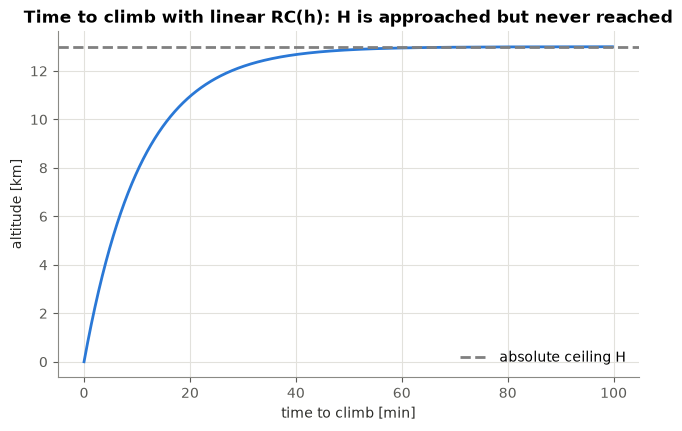

In [16]:
# Integrating directly in s makes SymPy pick a complex branch of log(h - H), because it
# does not know that h < H. Substitute y = 1 - s/H (ds = -H dy): y runs from 1 down to
# r = 1 - h/H, and r is declared POSITIVE, so the logarithm stays real.
y_, r_, H_, RC0_ = sp.symbols("y r H RC_0", positive=True)
t_sym = sp.integrate(H_ / (RC0_ * y_), (y_, r_, 1))
show("SymPy: t = integral_r^1 H/(RC_0 y) dy,  r = 1 - h/H", t_sym)

RC0_n, H_n = 20.0, 13_000.0                       # 20 m/s at sea level, ceiling 13 km
t_formula = lambda h: -H_n / RC0_n * np.log(1 - h / H_n)
from scipy.integrate import quad
for h_test in (5_000.0, 11_000.0, 12_900.0):
    t_quad, _ = quad(lambda s: 1 / (RC0_n * (1 - s / H_n)), 0, h_test, epsabs=0, epsrel=1e-12)
    check(f"t({h_test:.0f} m), numerical quadrature vs proved formula", t_quad, t_formula(h_test), 1e-9)

for M_min in (30, 60, 120):                        # altitude where the time reaches M
    h_M = H_n * (1 - np.exp(-M_min * 60 * RC0_n / H_n))
    print(f"t = {M_min:3d} min is reached at h = {h_M:8.1f} m  (H - h = {H_n - h_M:.2e} m)")

hh = np.linspace(0, 0.9999 * H_n, 2000)
fig, ax = plt.subplots()
ax.plot(t_formula(hh) / 60, hh / 1000)
ax.axhline(H_n / 1000, ls="--", color="gray", label="absolute ceiling H")
ax.set_xlabel("time to climb [min]"); ax.set_ylabel("altitude [km]")
ax.set_title("Time to climb with linear RC(h): H is approached but never reached")
ax.legend()
plt.show()

## 7. The ISA troposphere: existence and uniqueness of the pressure law

**Physical laws (hypotheses).** Hydrostatic equilibrium $dp/dh = -\rho g$, the ideal gas
$p = \rho RT$, and a linear temperature $T(h) = T_0 - Lh$ in the troposphere. Removing
$\rho$ gives
$$
\frac{dp}{dh} = -\frac{g\,p}{R\,(T_0 - Lh)} . \qquad (*)
$$

**Claims.**
1. The three laws imply $(*)$.
2. **Existence:** $p(h) = p_0\,\theta^{\,g/(LR)}$ with $\theta = 1 - Lh/T_0$ solves $(*)$.
3. **Uniqueness:** it is the **only** solution with $p(0)=p_0$ on any interval
   $[0, h_{max}]$ with $Lh_{max} < T_0$.
4. The density ratio is $\sigma = \rho/\rho_0 = \theta^{\,g/(LR)-1}$, the exponent
   $4.256$ of the ISA tables (notebook 07).

**Proof idea.** For any solution $p$, the function $q(h) = p(h)\,\theta(h)^{-n}$ with
$n = g/(LR)$ has derivative
$$
q' = \theta^{-n}\Big(p' + \frac{nL}{T_0}\frac{p}{\theta}\Big) = 0 ,
$$
so $q$ is constant on the interval by the mean value theorem
(`constant_of_has_deriv_right_zero`), and $q(0)=p_0$. The derivative of the real
power $\theta^{-n}$ uses Mathlib's `HasDerivAt.rpow_const`, which needs $\theta\ne0$:
this is where the hypothesis $Lh_{max}<T_0$ (positive temperature) is used.

In [17]:
show_lean("Atmosphere.lean", "ode_of_physics", "pressure_unique", "density_ratio")

`lean/AircraftPerformance/Atmosphere.lean`
```lean
/-- **Theorem 1.**  Hydrostatics (`p' = -ρ g`), ideal gas (`ρ = p / (R T)`) and the linear
lapse (`T = T₀ - L h`) give  `p' = -g p / (R (T₀ - L h))`. -/
theorem ode_of_physics {p ρ T : ℝ → ℝ} {T0 L g R h : ℝ}
    (hydro : HasDerivAt p (-(ρ h) * g) h) (gas : ρ h = p h / (R * T h))
    (lapse : T h = T0 - L * h) :
    HasDerivAt p (-(g / (R * (T0 - L * h))) * p h) h :=
  hydro.congr_deriv (by rw [gas, lapse]; ring)

/-- **Theorem 3 (uniqueness).**  Let `p` satisfy (*) on `[0, h_max]`, with `L h_max < T₀`,
and `p(0) = p₀`. Then `p(h) = p₀ (1 - L h / T₀)^{g/(L R)}` for every `h ∈ [0, h_max]`. -/
theorem pressure_unique {p : ℝ → ℝ} {hmax : ℝ} (hT0 : 0 < T0) (hL : 0 < L) (hR : 0 < R)
    (hceil : L * hmax < T0) (hp0 : p 0 = p0)
    (hode : ∀ h ∈ Set.Icc 0 hmax, HasDerivAt p (-(g / (R * (T0 - L * h))) * p h) h) :
    ∀ h ∈ Set.Icc 0 hmax, p h = pressureTropo p0 T0 L g R h := by
  -- θ > 0 on the whole interval
  have hθpos : ∀ h ∈ Set.Icc 0 hmax, 0 < 1 - L * h / T0 := by
    intro h hh
    apply theta_pos hT0
    -- L h ≤ L h_max < T₀
    linarith [mul_le_mul_of_nonneg_left hh.2 hL.le]
  -- q(h) = p(h) θ(h)^{-n} has zero derivative on [0, h_max]
  have hq : ∀ h ∈ Set.Icc 0 hmax,
      HasDerivAt (fun y => p y * (1 - L * y / T0) ^ (-(g / (L * R)))) 0 h := by
    intro h hh
    have hθ := hθpos h hh
    have h2 := (hasDerivAt_theta T0 L h).rpow_const (p := -(g / (L * R))) (Or.inl hθ.ne')
    have h3 := (hode h hh).mul h2
    convert h3 using 1
    rw [rpow_sub_one hθ.ne']
    generalize (1 - L * h / T0) ^ (-(g / (L * R))) = X
    have hθ' := hθ.ne'
    have hT : T0 - L * h ≠ 0 := by
      linarith [mul_le_mul_of_nonneg_left hh.2 hL.le]
    have hT0' := hT0.ne'
    have hL' := hL.ne'
    have hR' := hR.ne'
    field_simp <;> ring
  -- a function with zero derivative on [0, h_max] is constant there
  have hconst := constant_of_has_deriv_right_zero
    (fun x hx => (hq x hx).continuousAt.continuousWithinAt)
    (fun x hx => (hq x (Set.Ico_subset_Icc_self hx)).hasDerivWithinAt)
  intro h hh
  have hc := hconst h hh
  -- q(0) = p(0) · 1^{-n} = p₀
  simp only [mul_zero, zero_div, sub_zero, one_rpow, mul_one, hp0] at hc
  -- hence p(h) · (θ^n)⁻¹ = p₀, i.e. p(h) = p₀ θ^n
  have hθ := hθpos h hh
  rw [rpow_neg hθ.le] at hc
  unfold pressureTropo
  rw [← hc, inv_mul_cancel_right₀ (rpow_pos_of_pos hθ _).ne']

/-- **Theorem 4 (density ratio).**  With `ρ = p / (R T)` and `T = T₀ - L h`,
`σ = ρ(h) / ρ₀ = (1 - L h / T₀)^{g/(L R) - 1}`. -/
theorem density_ratio (hp0 : 0 < p0) (hT0 : 0 < T0) (hR : 0 < R) {h : ℝ} (hLh : L * h < T0) :
    (pressureTropo p0 T0 L g R h / (R * (T0 - L * h))) / (p0 / (R * T0))
      = (1 - L * h / T0) ^ (g / (L * R) - 1) := by
  have hθ := theta_pos hT0 hLh
  unfold pressureTropo
  rw [rpow_sub_one hθ.ne']
  generalize (1 - L * h / T0) ^ (g / (L * R)) = X
  have hθ' := hθ.ne'
  have hT : T0 - L * h ≠ 0 := by linarith
  have hT0' := hT0.ne'
  have hR' := hR.ne'
  have hp0' := hp0.ne'
  field_simp <;> ring
```

In [18]:
hs_, p0_, T0_, L_, g_, R_ = sp.symbols("h p_0 T_0 L g R", positive=True)
p_f = sp.Function("p")
ode = sp.Eq(p_f(hs_).diff(hs_), -g_ * p_f(hs_) / (R_ * (T0_ - L_ * hs_)))
isa_law = sp.Eq(p_f(hs_), p0_ * (1 - L_ * hs_ / T0_)**(g_ / (L_ * R_)))
show("proved solution", isa_law)
# checkodesol substitutes the solution into (*): (True, 0) means it satisfies the ODE.
# (sp.dsolve would also find it, but with log(L h - T0), a complex branch, since SymPy
# does not know that the temperature T0 - L h is positive.)
print("checkodesol:", sp.checkodesol(ode, isa_law))
assert sp.checkodesol(ode, isa_law)[0]

from aircraft_performance.atmosphere import isa, R_AIR, T0 as T0_ISA, P0 as P0_ISA, RHO0
L_ISA, g0 = 0.0065, u.G0
n_exp = g0 / (L_ISA * R_AIR)
print(f"n = g/(L R) = {n_exp:.5f},  density exponent n - 1 = {n_exp - 1:.5f}")
for h_test in (0.0, 3_000.0, 8_000.0, 11_000.0):
    theta = 1 - L_ISA * h_test / T0_ISA
    state = isa(h_test)
    check(f"p({h_test:.0f} m), package vs proved formula", state.pressure, P0_ISA * theta**n_exp, 1e-9)
    check(f"sigma({h_test:.0f} m), package vs proved formula", state.density / RHO0, theta**(n_exp - 1), 1e-9)

**proved solution:**

<IPython.core.display.Math object>

checkodesol: (True, 0)


n = g/(L R) = 5.25588,  density exponent n - 1 = 4.25588
  [OK] p(0 m), package vs proved formula: 101325  (reference 101325, difference 0 %)
  [OK] sigma(0 m), package vs proved formula: 1  (reference 1, difference 0 %)
  [OK] p(3000 m), package vs proved formula: 70108.5  (reference 70108.5, difference 0 %)
  [OK] sigma(3000 m), package vs proved formula: 0.74214  (reference 0.74214, difference 1.5e-14 %)
  [OK] p(8000 m), package vs proved formula: 35599.8  (reference 35599.8, difference 0 %)
  [OK] sigma(8000 m), package vs proved formula: 0.428708  (reference 0.428708, difference 1.3e-14 %)
  [OK] p(11000 m), package vs proved formula: 22632  (reference 22632, difference 0 %)
  [OK] sigma(11000 m), package vs proved formula: 0.297076  (reference 0.297076, difference 1.9e-14 %)


## 8. Machine check: running Lean

Two checks, both loud when they fail:

1. **No unfinished proofs.** Lean accepts a file containing `sorry` (a placeholder for a
   missing proof) with only a warning. `tools/check_lean_proofs.py` rejects `sorry`,
   `admit`, new `axiom`s and `native_decide` outside comments. This check is plain
   Python and always runs.
2. **`lake build`.** Lean re-checks every proof. It runs only if Lean is installed and
   Mathlib has been downloaded (`lake exe cache get` inside `lean/`); otherwise the cell
   says so explicitly. The continuous-integration workflow runs both checks on every push.

In [19]:
# 1. static check (always)
result = subprocess.run([sys.executable, str(ROOT / "tools" / "check_lean_proofs.py")],
                        capture_output=True, text=True)
print(result.stdout, result.stderr)
if result.returncode != 0:
    raise RuntimeError("unfinished proofs found (see the list above)")

Atmosphere.lean          6 theorems/lemmas: ode_of_physics, hasDerivAt_theta, theta_pos, hasDerivAt_pressureTropo, pressure_unique, density_ratio
Breguet.lean             6 theorems/lemmas: weight_history, endurance_time, breguet_range_jet, integral_const_mul_inv, breguet_of_hasDerivAt, log_ratio_pos
DragPolar.lean           9 theorems/lemmas: dragCoeff_pos, am_gm_core, am_gm_polar, dragCoeff_eq_iff, efficiency_le_eMax, efficiency_clE, efficiency_eq_eMax_iff, drag_ge_min, eMax_eq
Glide.lean               7 theorems/lemmas: glide_equilibrium, one_div_eMax, minGlideAngle_le, glideAngle_eq_min_iff, glideDistance_eq, glideDistance_le, glideDistance_eq_max_iff
JetClimb.lean            9 theorems/lemmas: drag_level_flight, rcW_eq, hasDerivAt_rcW, stationary_iff, quadratic_root_unique, bestSpeedSq_root, other_root_neg, rcW_le_of_stationary, rcW_le_best
MinPower.lean            7 theorems/lemmas: power_sq_eq, power_identity, power_factor_le, power_factor_clP, cube_div_sq_le, speedSq_clE, speed

In [20]:
# 2. lake build (only when Lean and the pre-compiled Mathlib are available)
lake = shutil.which("lake") or shutil.which(str(pathlib.Path.home() / ".elan" / "bin" / "lake"))
mathlib_ready = (LEAN_DIR / ".lake" / "packages" / "mathlib").is_dir()
if lake is None:
    print("Lean is NOT installed here: the proofs were NOT machine-checked in this run.\n"
          "Install the lean4 extension in VS Code (or elan), then inside lean/ run\n"
          "    lake exe cache get\n    lake build")
elif not mathlib_ready:
    print("Lean is installed but Mathlib has not been downloaded: the proofs were NOT checked.\n"
          f"Run, inside {LEAN_DIR}:\n    lake exe cache get\nand re-run this cell.")
else:
    print("Running lake build (the first build of the project takes a few minutes)...")
    build = subprocess.run([lake, "build"], cwd=LEAN_DIR, capture_output=True, text=True)
    print(build.stdout[-5000:], build.stderr[-5000:])
    if build.returncode != 0:
        raise RuntimeError("lake build failed: see the messages above")
    print("All proofs were checked by Lean.")

Lean is NOT installed here: the proofs were NOT machine-checked in this run.
Install the lean4 extension in VS Code (or elan), then inside lean/ run
    lake exe cache get
    lake build


## 9. Summary and exercises

| # | Main theorem (Lean name) | Statement |
|---|---|---|
| 1 | `efficiency_le_eMax`, `efficiency_eq_eMax_iff` | $C_L/C_D \le 1/(2\sqrt{C_{D0}K})$, equality only at $C_L=\sqrt{C_{D0}/K}$ |
| 2 | `glide_equilibrium`, `glideAngle_eq_min_iff`, `glideDistance_le` | $\gamma = \arctan(D/L)$; $\gamma_{min}$ and $x_{max}=hE_{max}$ only at point E |
| 3 | `cube_div_sq_le`, `speed_ratio_pow_four` | max $C_L^3/C_D^2$ at $\sqrt{3C_{D0}/K}$; $(V_E/V_P)^4=3$ |
| 4 | `quadratic_root_unique`, `other_root_neg`, `rcW_le_best` | Eqn 9.30 is the unique physical root and the global maximum |
| 5 | `weight_history`, `endurance_time`, `breguet_of_hasDerivAt` | $W=W_0e^{-ct}$ (unique); $t=\frac{E}{c_t}\ln\frac{W_0}{W_1}$; $R=k\ln\frac{W_0}{W_1}$ |
| 6 | `climbTime_eq`, `climbTime_unbounded` | $t=-\frac{H}{RC_0}\ln(1-h/H)$; the absolute ceiling is never reached |
| 7 | `pressure_unique`, `density_ratio` | $p=p_0\theta^{g/(LR)}$ is the unique solution; $\sigma=\theta^{g/(LR)-1}$ |

**Exercises** (open the `.lean` files in VS Code and watch the Infoview):

1. Delete the hypothesis `hK : 0 < K` from `efficiency_le_eMax`. Which step fails, and
   why is the theorem false for $K<0$?
2. Prove that point A, $C_{L,A} = \sqrt{C_{D0}/(3K)}$, maximises $C_L^{1/2}/C_D$ (best
   jet range at constant altitude, Roskam Eqn 11.66). Hint: maximise $C_L/C_D^2$ and look
   for an identity like the one in Proof 3 (let SymPy factorise it).
3. In `JetClimb.lean`, add the propeller case: $W\cdot RC = P - AV^3 - B/V$ with
   constant power $P$. Show that the optimum is point P of Proof 3.
4. Extend Proof 7 to the isothermal layer (11-20 km): $dp/dh = -g\,p/(RT_{11})$ has the
   unique solution $p = p_{11}e^{-g(h-h_{11})/(RT_{11})}$ (reuse the argument of
   `weight_history`).
5. Replace `rcW_le_best` by a **strict** statement: $RC(V) < RC(V^*)$ for $V\ne V^*$.